# 05 · Uncertainty quantification: m-SCP, m-CQR, ENS

Rebuilt from recorded per-sample test intervals, per-split calibration arrays ($M=2200$), checkpoints, and the conditional-coverage table.

### Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from _shared import (
    METHODS,
    METHOD_COLORS,
    METHOD_LABELS,
    N,
    ONE_HALF_COL,
    SINGLE_COL,
    init_notebook,
    jload,
    run_dir,
)

FIG_DIR, savefig = init_notebook("05_uncertainty")

campaign: dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/05_uncertainty


In [2]:
uq_dir = run_dir("xgboost", "conformal")
intervals = pd.read_csv(uq_dir / "test_intervals.csv")
convergence = pd.read_csv(uq_dir / "conformal_convergence.csv")
checkpoints = pd.read_csv(uq_dir / "conformal_checkpoints.csv")
uq_metrics = jload(uq_dir / "uq_metrics.json")
ALPHA = 0.1

required_checkpoint_columns = {
    "method", "M", "is_final", "q_hat", "picp", "mpiw",
    "wcc", "n_test", "nominal_coverage",
}
missing_checkpoint_columns = required_checkpoint_columns - set(checkpoints.columns)
if missing_checkpoint_columns:
    raise ValueError(
        f"conformal checkpoint columns missing: {sorted(missing_checkpoint_columns)}"
    )
if checkpoints[list(required_checkpoint_columns)].isna().any().any():
    raise ValueError("conformal checkpoint table contains missing values")

expected_checkpoint_rows = [
    ("scp", 100), ("scp", 500), ("scp", 2200),
    ("cqr", 100), ("cqr", 500), ("cqr", 2200),
]
observed_checkpoint_rows = list(
    checkpoints[["method", "M"]].itertuples(index=False, name=None)
)
if observed_checkpoint_rows != expected_checkpoint_rows:
    raise ValueError(f"unexpected conformal checkpoints: {observed_checkpoint_rows}")
if set(uq_metrics) != set(METHODS):
    raise ValueError(f"unexpected UQ methods: {sorted(uq_metrics)}")

for method in ("scp", "cqr"):
    final_row = checkpoints[(checkpoints["method"] == method) & checkpoints["is_final"]]
    if len(final_row) != 1:
        raise ValueError(f"expected one final checkpoint for {method}")
    final_row = final_row.iloc[0]
    for column, metric in (("q_hat", "q_hat"), ("picp", "picp"), ("mpiw", "mpiw"), ("wcc", "wcc")):
        if not np.isclose(final_row[column], uq_metrics[method][metric]):
            raise ValueError(f"final {method} {column} disagrees with uq_metrics.json")

In [3]:
publication_uq_table = pd.DataFrame(
    {
        "Method": checkpoints["method"].map(METHOD_LABELS),
        "M": checkpoints["M"].astype(int).astype(str),
        "Correction": checkpoints["q_hat"].map(lambda value: f"q̄ = {value:.2f}"),
        "Test PICP": checkpoints["picp"].map(lambda value: f"{value:.2f}"),
        "Test MPIW": checkpoints["mpiw"].map(lambda value: f"{value:.2f}"),
        "WCC": checkpoints["wcc"].map(lambda value: f"{value:.2f}"),
    }
)
ensemble_row = pd.DataFrame(
    [
        {
            "Method": METHOD_LABELS["ens"],
            "M": "—",
            "Correction": f"z = {uq_metrics['ens']['z']:.2f}",
            "Test PICP": f"{uq_metrics['ens']['picp']:.2f}",
            "Test MPIW": f"{uq_metrics['ens']['mpiw']:.2f}",
            "WCC": "—",
        }
    ]
)
publication_uq_table = pd.concat(
    [publication_uq_table, ensemble_row], ignore_index=True
)

print(f"checkpoint source: {uq_dir / 'conformal_checkpoints.csv'}")
print(f"final ensemble source: {uq_dir / 'uq_metrics.json'}")
display(
    publication_uq_table.style
    .hide(axis="index")
    .set_caption("Publication UQ checkpoints")
)

checkpoint source: /Users/berthier/Development/PhD/xopa/results/final-campaigns/dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11/xgboost/2026-08-11_18-28-23_conformal_xgboost/conformal_checkpoints.csv
final ensemble source: /Users/berthier/Development/PhD/xopa/results/final-campaigns/dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11/xgboost/2026-08-11_18-28-23_conformal_xgboost/uq_metrics.json


Method,M,Correction,Test PICP,Test MPIW,WCC
m-SCP,100,q̄ = 0.66,0.90,1.32,0.84
m-SCP,500,q̄ = 0.66,0.90,1.32,0.84
m-SCP,2200,q̄ = 0.66,0.90,1.32,0.83
m-CQR,100,q̄ = 0.12,0.90,1.69,0.86
m-CQR,500,q̄ = 0.12,0.90,1.69,0.85
m-CQR,2200,q̄ = 0.12,0.90,1.69,0.84
ENS,—,z = 6.74,0.90,1.50,—


## Conditional coverage by target value

Coverage is evaluated in 0.5-wide target bins with approximate 95 percent binomial intervals. This shows how the marginal average is distributed across densely and sparsely populated parts of the target range.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/05_uncertainty/coverage_by_output_bin.pdf/.png


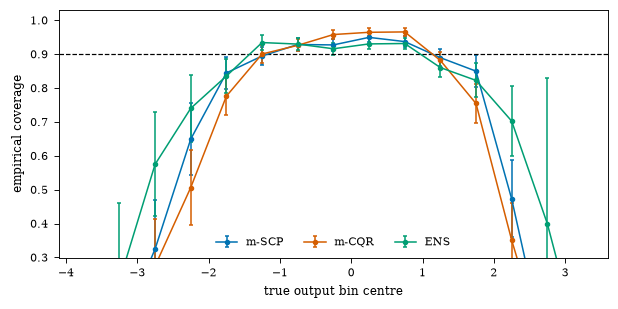

In [4]:
edges = np.arange(-4.0, 4.01, 0.5)
fig, ax = plt.subplots(figsize=(ONE_HALF_COL, 2.7))
for method in METHODS:
    block = intervals[intervals["method"] == method]
    bins = pd.cut(block["y_true"], edges)
    grouped = block.groupby(bins, observed=True)["covered"]
    centers = [iv.mid for iv in grouped.mean().index]
    coverage = grouped.mean().to_numpy()
    n = grouped.count().to_numpy()
    half = 1.96 * np.sqrt(np.clip(coverage * (1 - coverage), 1e-9, None) / n)
    ax.errorbar(centers, coverage, yerr=half, marker="o", ms=2.6, lw=1.0,
                capsize=1.5, color=METHOD_COLORS[method], label=METHOD_LABELS[method])
ax.axhline(1 - ALPHA, color="black", ls="--", lw=0.8)
ax.set_xlabel("true output bin centre")
ax.set_ylabel("empirical coverage")
ax.set_ylim(0.3, 1.03)
ax.legend(loc="lower center", ncol=3)
savefig(fig, "coverage_by_output_bin")
plt.show()

## The $M$-split machinery: per-split coverages and convergence

Left: distribution of the 2,200 per-split evaluation coverages (WCC is the minimum).  
Right: running average with the finite-sample band; $M=100$ and $M=2200$ are indistinguishable.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/05_uncertainty/msplit_distribution_and_convergence.pdf/.png


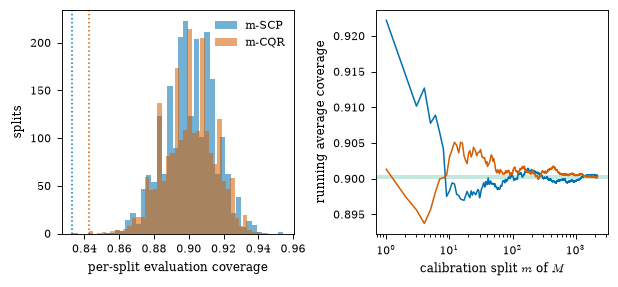

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(ONE_HALF_COL, 2.5))
for method in ("scp", "cqr"):
    block = convergence[convergence["method"] == method]
    ax1.hist(block["eval_coverage"], bins=40, alpha=0.55,
             color=METHOD_COLORS[method], label=METHOD_LABELS[method])
    ax2.plot(block["split_number"], block["running_coverage"],
             color=METHOD_COLORS[method], lw=1.0)
    ax2.axhspan(block["nominal_coverage"].iloc[0], block["finite_sample_upper"].iloc[0],
                color="#009E73", alpha=0.12, lw=0)
wcc = {m: uq_metrics[m]["wcc"] for m in ("scp", "cqr")}
ax1.axvline(wcc["scp"], color=METHOD_COLORS["scp"], ls=":", lw=1.0)
ax1.axvline(wcc["cqr"], color=METHOD_COLORS["cqr"], ls=":", lw=1.0)
ax1.set_xlabel("per-split evaluation coverage")
ax1.set_ylabel("splits")
ax1.legend()
ax2.set_xscale("log")
ax2.set_xlabel(f"calibration split $m$ of {N['M']}")
ax2.set_ylabel("running average coverage")
savefig(fig, "msplit_distribution_and_convergence")
plt.show()

## Coverage within the post-hoc chronological window

This descriptive comparison reuses the four-group window [22500, 28499] selected from the exploratory SHAP profile. It is not a pre-specified subgroup or an estimated production regime.

conditional source: /Users/berthier/Development/PhD/xopa/results/final-campaigns/dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11/xgboost/2026-08-11_18-28-23_conformal_xgboost/conditional_coverage.csv


Method,Post-hoc window PICP,Remaining test PICP,Difference (percentage points)
m-SCP,0.88,0.90,-2.33
m-CQR,0.89,0.90,-1.02
ENS,0.89,0.90,-0.58


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/05_uncertainty/regime_conditional_coverage.pdf/.png


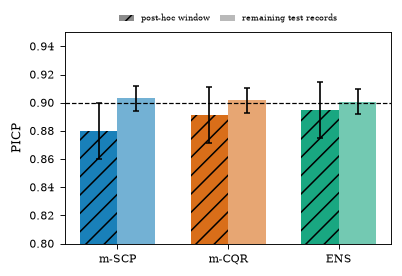

In [6]:
conditional = pd.read_csv(uq_dir / "conditional_coverage.csv")
required_conditional_columns = {"method", "group", "n", "picp", "mpiw"}
missing_conditional_columns = required_conditional_columns - set(conditional.columns)
if missing_conditional_columns:
    raise ValueError(
        f"conditional coverage columns missing: {sorted(missing_conditional_columns)}"
    )

inside = conditional[conditional["group"] == "records_22500_28499"]
outside = conditional[conditional["group"] == "records_rest"]
inside_by_method = inside.set_index("method").loc[METHODS]
outside_by_method = outside.set_index("method").loc[METHODS]
if not (inside_by_method["n"] == 866).all():
    raise ValueError("unexpected test-record count inside the chronological window")
if not (outside_by_method["n"] == 4403).all():
    raise ValueError("unexpected test-record count outside the chronological window")

window_coverage_gap_pp = 100 * (
    inside_by_method["picp"] - outside_by_method["picp"]
)
publication_window_table = pd.DataFrame(
    {
        "Method": [METHOD_LABELS[method] for method in METHODS],
        "Post-hoc window PICP": inside_by_method["picp"].map(lambda value: f"{value:.2f}").to_numpy(),
        "Remaining test PICP": outside_by_method["picp"].map(lambda value: f"{value:.2f}").to_numpy(),
        "Difference (percentage points)": window_coverage_gap_pp.map(lambda value: f"{value:.2f}").to_numpy(),
    }
)

print(f"conditional source: {uq_dir / 'conditional_coverage.csv'}")
display(
    publication_window_table.style
    .hide(axis="index")
    .set_caption("Chronological-window coverage gaps")
)

fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.4))
x = np.arange(3)
for offset, block, label, hatch in (
    (-0.17, inside, "post-hoc window (n=866)", "//"),
    (0.17, outside, "remaining test records (n=4403)", None),
):
    coverage = block.set_index("method").loc[METHODS, "picp"]
    n = block.set_index("method").loc[METHODS, "n"]
    half = 1.96 * np.sqrt(0.9 * 0.1 / n)
    ax.bar(x + offset, coverage, 0.34, yerr=half, capsize=2,
           color=[METHOD_COLORS[m] for m in METHODS], alpha=0.9 if hatch else 0.55,
           hatch=hatch, label=label)
ax.axhline(0.9, color="black", ls="--", lw=0.8)
ax.set_xticks(x, [METHOD_LABELS[m] for m in METHODS])
ax.set_ylim(0.8, 0.95)
ax.set_ylabel("PICP")
handles = [
    plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.9, hatch="//", label="post-hoc window"),
    plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.55, label="remaining test records"),
]
ax.legend(
    handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.01),
    ncol=2, fontsize=5.5, columnspacing=1.2, handlelength=1.8,
)
savefig(fig, "regime_conditional_coverage")
plt.show()